In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset

df = pd.read_csv("movie recomendation.csv")

In [4]:
# Display the first 5 rows of the dataset

df.head()

,movie_id,movie_title,movie_genre,release_date,movie_ratings
0,1,Dark Memory,Animation,2009-10-25,1.6
1,2,Infinite Destiny,Crime,2014-02-28,2.7
2,3,Silent Phoenix,History,1998-08-29,3.1
3,4,Shining Promise,Sport,2011-04-09,1.7
4,5,Dark Guardian,Adventure,2017-10-06,4.2


In [5]:
# Display the last 5 rows of the dataset

df.tail()

,movie_id,movie_title,movie_genre,release_date,movie_ratings
295,296,Silver Chronicle,Sport,1994-03-15,3.0
296,297,Silver Signal,Thriller,2007-04-27,4.7
297,298,Emerald Code,Drama,1983-11-10,1.5
298,299,Hidden Empire,Western,2006-04-03,4.1
299,300,Lost Promise,Thriller,2021-07-11,1.5


In [6]:
# Check the shape of the dataset

df.shape

(300, 5)

In [7]:
# Display all column names

df.columns

Index(['movie_id', 'movie_title', 'movie_genre', 'release_date',
       'movie_ratings'],
      dtype='object')

In [8]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   movie_id       300 non-null    int64  
 1   movie_title    300 non-null    object 
 2   movie_genre    300 non-null    object 
 3   release_date   300 non-null    object 
 4   movie_ratings  300 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 11.8+ KB


In [9]:
# Display summary statistics

df.describe()

,movie_id,movie_ratings
count,300.000000,300.000000
mean,150.500000,3.000667
std,86.746758,1.195252
min,1.000000,1.000000
25%,75.750000,1.975000
50%,150.500000,2.900000
75%,225.250000,4.025000
max,300.000000,5.000000


In [10]:
# Check for missing values

df.isnull().sum()

,0
movie_id,0
movie_title,0
movie_genre,0
release_date,0
movie_ratings,0


In [11]:
# Check for duplicate rows

df.duplicated().sum()

np.int64(0)

In [12]:
# Remove duplicate rows

df = df.drop_duplicates().reset_index(drop=True)

# Verify duplicates have been removed
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
# Check missing values

print("Missing Values:\n")
print(df.isnull().sum())

# Fill missing values (if any)

df['movie_title'].fillna('Unknown', inplace=True)
df['movie_genre'].fillna(df['movie_genre'].mode()[0], inplace=True)
df['movie_ratings'].fillna(df['movie_ratings'].mean(), inplace=True)
df['release_date'].fillna(df['release_date'].mode()[0], inplace=True)

# Verify missing values have been handled

print("\nMissing Values After Handling:\n")
print(df.isnull().sum())

Missing Values:

movie_id         0
movie_title      0
movie_genre      0
release_date     0
movie_ratings    0
dtype: int64

Missing Values After Handling:

movie_id         0
movie_title      0
movie_genre      0
release_date     0
movie_ratings    0
dtype: int64


In [14]:
# Convert release_date to datetime format

df['release_date'] = pd.to_datetime(df['release_date'])

# Check the data type
print(df['release_date'].dtype)

datetime64[ns]


In [15]:
# Extract release year from release_date

df['release_year'] = df['release_date'].dt.year

# Display the first 5 rows with the new column

df[['movie_title', 'release_date', 'release_year']].head()

,movie_title,release_date,release_year
0,Dark Memory,2009-10-25,2009
1,Infinite Destiny,2014-02-28,2014
2,Silent Phoenix,1998-08-29,1998
3,Shining Promise,2011-04-09,2011
4,Dark Guardian,2017-10-06,2017


In [ ]:
# Dataset Overview

print("Shape of Dataset:", df.shape)
print("\n")

print("Columns:")
print(df.columns.tolist())
print("\n")

print("Data Types:")
print(df.dtypes)
print("\n")

print("Missing Values:")
print(df.isnull().sum())
print("\n")

print("Duplicate Rows:", df.duplicated().sum())

Shape of Dataset: (300, 6)


Columns:
['movie_id', 'movie_title', 'movie_genre', 'release_date', 'movie_ratings', 'release_year']


Data Types:
movie_id                  int64
movie_title              object
movie_genre              object
release_date     datetime64[ns]
movie_ratings           float64
release_year              int32
dtype: object


Missing Values:
movie_id         0
movie_title      0
movie_genre      0
release_date     0
movie_ratings    0
release_year     0
dtype: int64


Duplicate Rows: 0


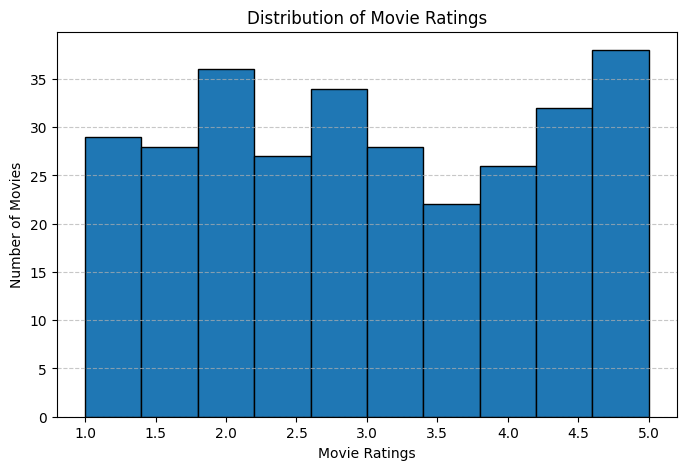

In [17]:
# ==========================================
# Distribution of Movie Ratings
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(df['movie_ratings'], bins=10, edgecolor='black')

plt.title("Distribution of Movie Ratings")
plt.xlabel("Movie Ratings")
plt.ylabel("Number of Movies")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

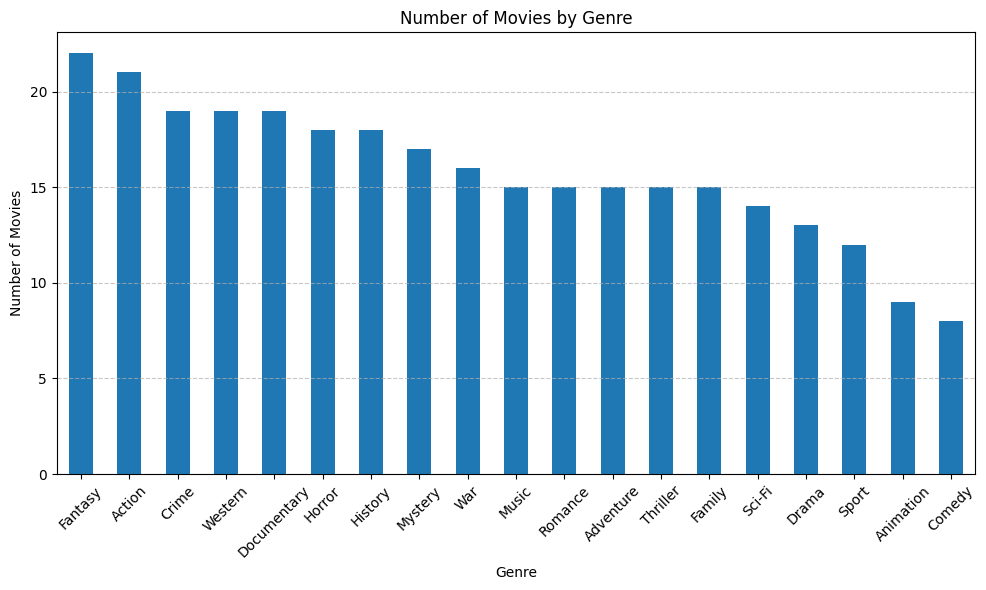

In [ ]:
# Count of Movies by Genre
genre_counts = df['movie_genre'].value_counts()

plt.figure(figsize=(10,6))

genre_counts.plot(kind='bar')

plt.title("Number of Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

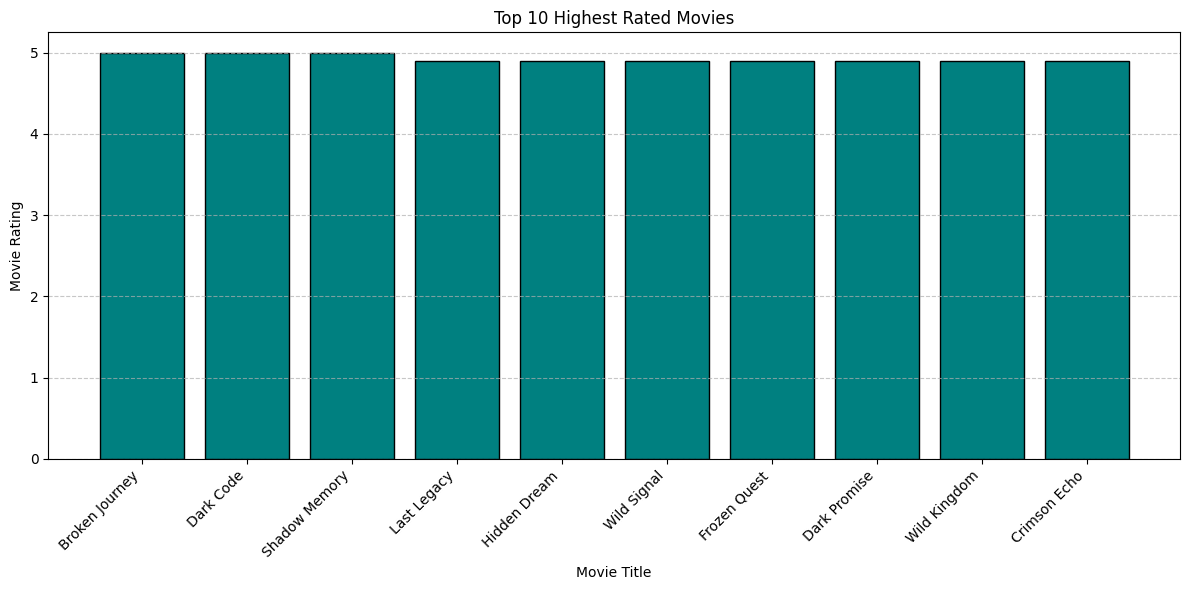

In [ ]:
# Top 10 Highest Rated Movies

top_movies = df.sort_values(by='movie_ratings', ascending=False).head(10)

plt.figure(figsize=(12,6))

plt.bar(top_movies['movie_title'], top_movies['movie_ratings'],color='teal', edgecolor='black')

plt.title("Top 10 Highest Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Movie Rating")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

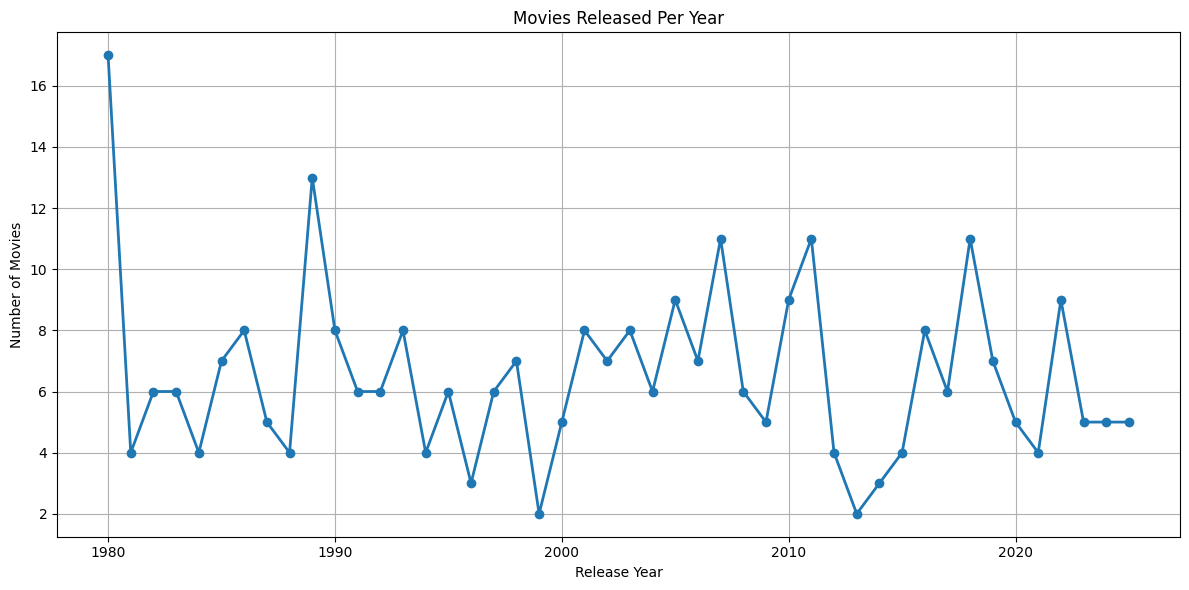

In [ ]:
# Movies Released Per Year

movies_per_year = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))

plt.plot(
    movies_per_year.index,
    movies_per_year.values,
    marker='o',
    linewidth=2
)

plt.title("Movies Released Per Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.grid(True)

plt.tight_layout()
plt.show()

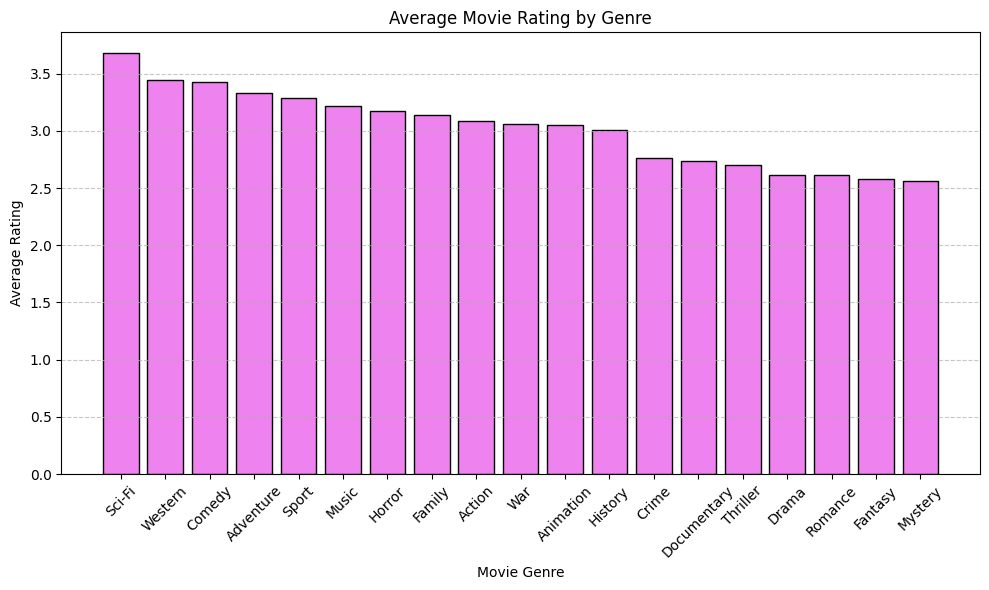

In [ ]:
# Average Movie Rating by Genre
avg_rating = (
    df.groupby('movie_genre')['movie_ratings']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

plt.bar(avg_rating.index, avg_rating.values,color='violet', edgecolor='black')

plt.title("Average Movie Rating by Genre")
plt.xlabel("Movie Genre")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

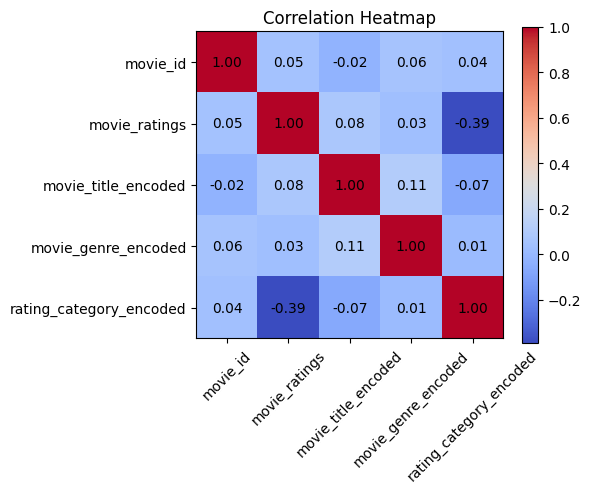

In [ ]:
# Correlation Heatmap

import matplotlib.pyplot as plt

# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation
correlation = numeric_df.corr()

# Plot heatmap using matplotlib
plt.figure(figsize=(6,5))

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")

# Display correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i,
                 f"{correlation.iloc[i, j]:.2f}",
                 ha='center',
                 va='center',
                 color='black')

plt.tight_layout()
plt.show()

In [ ]:
# Create Rating Category
def rating_category(rating):
    if rating < 2:
        return "Poor"
    elif rating < 3:
        return "Average"
    elif rating < 4:
        return "Good"
    else:
        return "Excellent"

# Create new column
df['rating_category'] = df['movie_ratings'].apply(rating_category)

# Display first 10 rows
df[['movie_title', 'movie_ratings', 'rating_category']].head(10)

,movie_title,movie_ratings,rating_category
0,Dark Memory,1.6,Poor
1,Infinite Destiny,2.7,Average
2,Silent Phoenix,3.1,Good
3,Shining Promise,1.7,Poor
4,Dark Guardian,4.2,Excellent
5,Infinite Odyssey,4.6,Excellent
6,Eternal Signal,4.3,Excellent
7,Silent Flame,2.9,Average
8,Infinite Kingdom,2.9,Average
9,Burning Legacy,2.2,Average


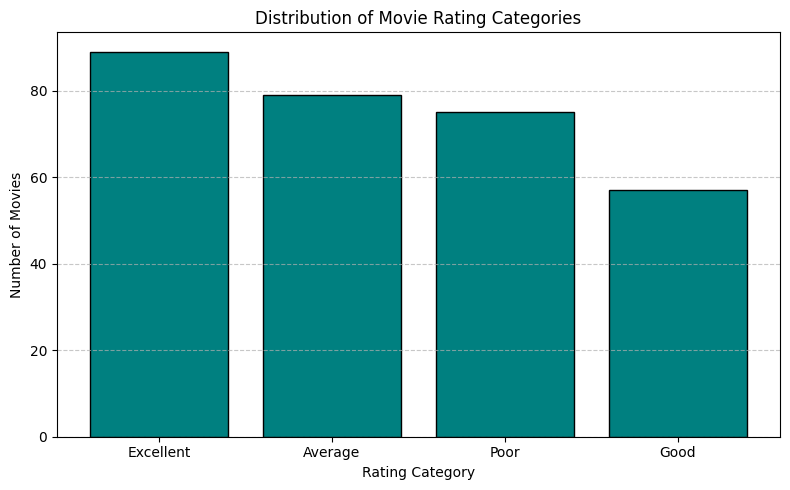

In [ ]:
# Distribution of Rating Categories

rating_counts = df['rating_category'].value_counts()
plt.figure(figsize=(8,5))
plt.bar(rating_counts.index, rating_counts.values,color='teal', edgecolor='black')
plt.title("Distribution of Movie Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Number of Movies")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le_title = LabelEncoder()
le_genre = LabelEncoder()
le_category = LabelEncoder()

# Encode categorical columns
df['movie_title_encoded'] = le_title.fit_transform(df['movie_title'])
df['movie_genre_encoded'] = le_genre.fit_transform(df['movie_genre'])
df['rating_category_encoded'] = le_category.fit_transform(df['rating_category'])

# Display encoded data
df[['movie_title',
    'movie_title_encoded',
    'movie_genre',
    'movie_genre_encoded',
    'rating_category',
    'rating_category_encoded']].head()

,movie_title,movie_title_encoded,movie_genre,movie_genre_encoded,rating_category,rating_category_encoded
0,Dark Memory,55,Animation,2,Poor,3
1,Infinite Destiny,120,Crime,4,Average,0
2,Silent Phoenix,194,History,9,Good,2
3,Shining Promise,182,Sport,15,Poor,3
4,Dark Guardian,50,Adventure,1,Excellent,1


In [ ]:
# Define Features (X) and Target (y)
# Features
X = df[['movie_genre_encoded', 'release_year', 'movie_ratings']]

# Target
y = df['rating_category_encoded']

# Display features and target
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   movie_genre_encoded  release_year  movie_ratings
0                    2          2009            1.6
1                    4          2014            2.7
2                    9          1998            3.1
3                   15          2011            1.7
4                    1          2017            4.2

Target (y):
0    3
1    0
2    2
3    3
4    1
Name: rating_category_encoded, dtype: int64


In [ ]:
# Split the Dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target  :", y_train.shape)
print("Testing Target   :", y_test.shape)

Training Features: (240, 3)
Testing Features : (60, 3)
Training Target  : (240,)
Testing Target   : (60,)


In [ ]:
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print("========== Logistic Regression ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

========== Logistic Regression ==========
Accuracy : 0.95

Confusion Matrix:
[[15  0  1  0]
 [ 0 17  1  0]
 [ 0  1 10  0]
 [ 0  0  0 15]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        16
           1       0.94      0.94      0.94        18
           2       0.83      0.91      0.87        11
           3       1.00      1.00      1.00        15

    accuracy                           0.95        60
   macro avg       0.94      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



In [ ]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
print("========== Decision Tree Classifier ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

========== Decision Tree Classifier ==========
Accuracy : 1.0

Confusion Matrix:
[[16  0  0  0]
 [ 0 18  0  0]
 [ 0  0 11  0]
 [ 0  0  0 15]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        15

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



In [ ]:
# K-Nearest Neighbors (KNN) Classifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
print("========== KNN Classifier ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

========== KNN Classifier ==========
Accuracy : 0.4

Confusion Matrix:
[[8 2 3 3]
 [6 9 3 0]
 [5 2 2 2]
 [9 0 1 5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.50      0.36        16
           1       0.69      0.50      0.58        18
           2       0.22      0.18      0.20        11
           3       0.50      0.33      0.40        15

    accuracy                           0.40        60
   macro avg       0.43      0.38      0.39        60
weighted avg       0.45      0.40      0.41        60



In [ ]:
# Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("========== Random Forest Classifier ==========")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

========== Random Forest Classifier ==========
Accuracy : 1.0

Confusion Matrix:
[[16  0  0  0]
 [ 0 18  0  0]
 [ 0  0 11  0]
 [ 0  0  0 15]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        15

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



                 Model  Accuracy
1        Decision Tree      1.00
3        Random Forest      1.00
0  Logistic Regression      0.95
2                  KNN      0.40


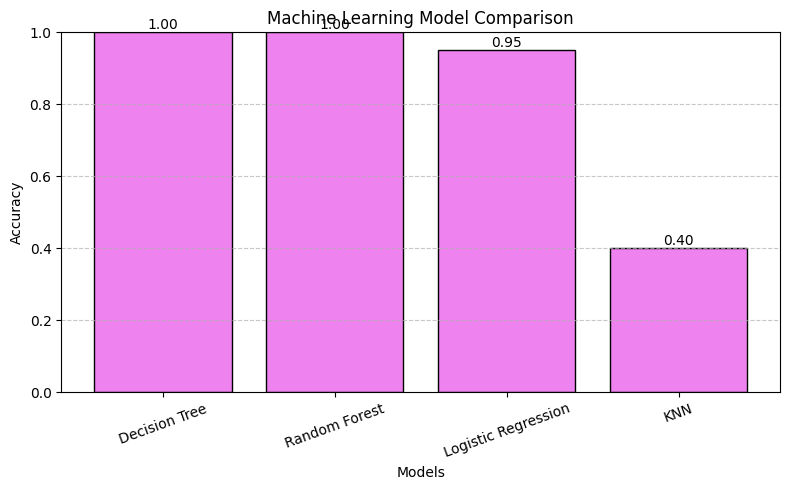

In [ ]:
# Compare All Machine Learning Models

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Store accuracy scores
model_accuracy = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf)
    ]
})

# Sort by accuracy
model_accuracy = model_accuracy.sort_values(by='Accuracy', ascending=False)

# Display accuracy table
print(model_accuracy)

# Plot accuracy comparison
plt.figure(figsize=(8,5))
plt.bar(model_accuracy['Model'], model_accuracy['Accuracy'],color='violet', edgecolor='black')

plt.title("Machine Learning Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)
plt.ylim(0, 1)

# Display accuracy values on bars
for index, value in enumerate(model_accuracy['Accuracy']):
    plt.text(index, value + 0.01, f"{value:.2f}", ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Movie Recommendation System

def recommend_movies(genre, top_n=10):
    """
    Recommend top-rated movies from a selected genre.

    Parameters:
        genre (str): Movie genre
        top_n (int): Number of movies to recommend

    Returns:
        DataFrame of recommended movies
    """

    # Filter movies by genre
    recommended = df[df['movie_genre'].str.lower() == genre.lower()]

    # Check if genre exists
    if recommended.empty:
        print(f"No movies found for genre: {genre}")
        return None

    # Sort by rating (highest first)
    recommended = recommended.sort_values(
        by='movie_ratings',
        ascending=False
    )

    # Return selected columns
    return recommended[
        ['movie_title',
         'movie_genre',
         'movie_ratings',
         'release_year']
    ].head(top_n)

In [ ]:
# Test the Recommendation System

# Recommend Top 10 Action movies
recommendations = recommend_movies("Action", top_n=10)

# Display recommendations
print("Top 10 Recommended Movies:\n",recommendations)


Top 10 Recommended Movies:
         movie_title movie_genre  movie_ratings  release_year
114       Dark Code      Action            5.0          2022
82     Wild Kingdom      Action            4.9          2023
190  Broken Journey      Action            4.9          2007
15     Wild Promise      Action            4.9          1998
145  Crimson Legacy      Action            4.4          1992
257    Golden Quest      Action            4.4          1986
25   Hidden Phoenix      Action            4.0          2010
95   Burning Legacy      Action            3.8          2010
254     Silent Echo      Action            3.7          1994
235  Golden Destiny      Action            3.4          1995


In [ ]:
# Recommend Similar Movies by Movie Title

def recommend_by_movie(movie_title, top_n=10):

    # Check if the movie exists
    movie = df[df['movie_title'].str.lower() == movie_title.lower()]

    if movie.empty:
        print("Movie not found!")
        return

    # Get the movie genre
    genre = movie.iloc[0]['movie_genre']

    # Recommend movies from the same genre
    recommendations = df[
        (df['movie_genre'] == genre) &
        (df['movie_title'] != movie_title)
    ].sort_values(
        by='movie_ratings',
        ascending=False
    )

    return recommendations[
        ['movie_title',
         'movie_genre',
         'movie_ratings',
         'release_year']
    ].head(top_n)

In [ ]:
recommend_by_movie("Dark Horizon")

,movie_title,movie_genre,movie_ratings,release_year
206,Shadow Memory,Horror,5.0,2020
256,Hidden Dream,Horror,4.9,1986
87,Silent Chronicle,Horror,4.8,2003
57,Midnight Dream,Horror,4.7,1989
175,Frozen Phoenix,Horror,4.5,2004
227,Emerald Empire,Horror,4.0,1988
62,Emerald Odyssey,Horror,3.7,1980
282,Eternal Memory,Horror,2.9,2018
55,Infinite Empire,Horror,2.9,2017
146,Silent Destiny,Horror,2.8,1985


In [ ]:
# Display the first 20 movie titles

df['movie_title'].head(20)

,movie_title
0,Dark Memory
1,Infinite Destiny
2,Silent Phoenix
3,Shining Promise
4,Dark Guardian
5,Infinite Odyssey
6,Eternal Signal
7,Silent Flame
8,Infinite Kingdom
9,Burning Legacy


In [ ]:
# Test Recommendation by Movie Title
recommendations = recommend_by_movie("Shadow Destiny")
print("Recommended Movies:\n",recommendations)


Recommended Movies:
             movie_title movie_genre  movie_ratings  release_year
51   Infinite Chronicle         War            4.2          1997
53         Shadow River         War            4.2          1980
292    Secret Chronicle         War            4.1          2004
69       Golden Odyssey         War            4.0          1989
18       Eternal Signal         War            4.0          2022
140        Secret Storm         War            3.7          2024
126      Eternal Signal         War            3.0          1982
7          Silent Flame         War            2.9          2005
111      Wild Chronicle         War            2.7          1981
20         Dark Kingdom         War            2.6          1980


In [ ]:
# Import Libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Create TF-IDF Matrix

# Fill missing genres if any
df['movie_genre'] = df['movie_genre'].fillna('Unknown')

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Convert genres into TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(df['movie_genre'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (300, 20)


In [ ]:
# Compute Cosine Similarity

cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print("Cosine Similarity Matrix Shape:", cosine_sim.shape)

Cosine Similarity Matrix Shape: (300, 300)


In [ ]:
# TF-IDF Based Movie Recommendation Function

# Create a mapping from movie title to index
indices = pd.Series(df.index, index=df['movie_title']).drop_duplicates()

def content_recommendation(movie_title, top_n=10):

    # Check if movie exists
    if movie_title not in indices:
        return f"Movie '{movie_title}' not found in the dataset."

    # Get movie index
    idx = indices[movie_title]

    # Get similarity scores
    similarity_scores = list(enumerate(cosine_sim[idx]))

    # Sort by similarity
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Remove the selected movie
    similarity_scores = similarity_scores[1:top_n+1]

    # Get movie indices
    movie_indices = [i[0] for i in similarity_scores]

    # Return recommended movies
    return df.iloc[movie_indices][[
        'movie_title',
        'movie_genre',
        'movie_ratings',
        'release_year'
    ]]

In [ ]:
# Display first 20 movie titles

df['movie_title'].head(20)

,movie_title
0,Dark Memory
1,Infinite Destiny
2,Silent Phoenix
3,Shining Promise
4,Dark Guardian
5,Infinite Odyssey
6,Eternal Signal
7,Silent Flame
8,Infinite Kingdom
9,Burning Legacy


In [ ]:
# Test the TF-IDF Recommendation System
movie_name = "Burning legacy"

recommendations = content_recommendation(movie_name, top_n=10)

print(f"\nTop 10 Movies Similar to '{movie_name}':\n",recommendations)



Top 10 Movies Similar to 'Burning legacy':
 Movie 'Burning legacy' not found in the dataset.
